# Layout Spec, Process Stack, and Simulation Layout

This notebook demonstrates the translation pipeline from a parametric 2D gate layout to a structured 3D simulation-ready device description.

The goal is to:
- build a quantum dot layout using the reusable device builders
- extract the layout spec
- define the vertical process stack
- combine both into a simulation-ready representation that can later be translated into a nextnano input file

## 0. Setup

### 0.1 Imports

In [1]:
import sys
from pathlib import Path
import json
import pprint

sys.path.append(str(Path("../../src").resolve()))

from phidl import quickplot as qp

from qd_design import (
    LinearDotArrayDevice,
    SingleDotDevice,
    make_sige_ge_process_stack,
    make_reference_sige_ge_process_stack,
    build_simulation_layout,
)

### 0.2 Helper Functions

In [2]:
def print_json(data):
    print(json.dumps(data, indent=2))


def print_header(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

### 0.3 Configs

In [3]:
OUTPUT_DIR = Path("../../data/gds")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE_CONFIG = {
    "name": "single_dot_for_translation_pipeline",
    "device_y_size_nm": 200.0,
    "ohmic_width_nm": 40.0,
    "ohmic_length_nm": 200.0,
    "barrier_width_nm": 40.0,
    "barrier_length_nm": 140.0,
    "plunger_body_width_nm": 40.0,
    "plunger_body_length_nm": 50.0,
    "plunger_head_top_width_nm": 60.0,
    "plunger_head_max_width_nm": 100.0,
    "plunger_head_height_nm": 100.0,
    "plunger_upper_taper_height_nm": 25.0,
    "plunger_lower_taper_height_nm": 25.0,
    "ohmic_to_barrier_gap_nm": 20.0,
    "barrier_to_plunger_gap_nm": 20.0,
}

STACK_CONFIG = {
    "name": "reference_process_stack",
}

## 1. Build the 2D Layout

### 1.1 Instantiate the Device Builder

In [4]:
device = SingleDotDevice(**DEVICE_CONFIG)
layout = device.ensure_built()

print(device.summary())

{'name': 'single_dot_for_translation_pipeline', 'device_y_size_nm': 200.0, 'ohmic_width_nm': 40.0, 'ohmic_length_nm': 200.0, 'barrier_width_nm': 40.0, 'barrier_length_nm': 140.0, 'plunger_body_width_nm': 40.0, 'plunger_body_length_nm': 50.0, 'plunger_head_top_width_nm': 60.0, 'plunger_head_max_width_nm': 100.0, 'plunger_head_height_nm': 100.0, 'plunger_upper_taper_height_nm': 25.0, 'plunger_lower_taper_height_nm': 25.0, 'ohmic_to_barrier_gap_nm': 20.0, 'barrier_to_plunger_gap_nm': 20.0}


### 1.2 Visualize the Layout

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


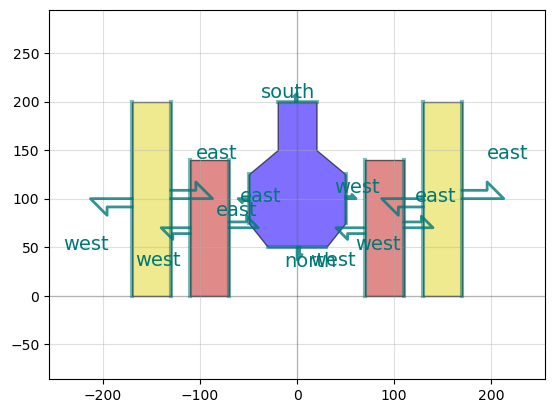

In [5]:
qp(layout)

### 1.3 Export the Layout

In [6]:
device.write_gds(str(OUTPUT_DIR / "single_dot_translation_pipeline.gds"))
device.write_svg(str(OUTPUT_DIR / "single_dot_translation_pipeline.svg"))

print("Saved layout files.")

Saved layout files.


## 2. Extract the Layout Spec

### 2.1 Inspect the Structured Layout Spec

In [7]:
layout_spec = device.layout_spec()

print_header("Layout Spec")
print_json(layout_spec)


Layout Spec
[
  {
    "name": "OC_L",
    "gate_type": "ohmic",
    "layer_name": "ohmic",
    "gds_layer": 3,
    "gds_datatype": 0,
    "voltage_label": "V_OC_L",
    "role": null,
    "notes": null,
    "x_min_nm": -170.0,
    "y_min_nm": 0.0,
    "x_max_nm": -130.0,
    "y_max_nm": 200.0,
    "center_x_nm": -150.0,
    "center_y_nm": 100.0,
    "width_nm": 40.0,
    "height_nm": 200.0,
    "params": {
      "width_nm": 40.0,
      "length_nm": 200.0
    }
  },
  {
    "name": "B_L",
    "gate_type": "barrier",
    "layer_name": "barrier",
    "gds_layer": 2,
    "gds_datatype": 0,
    "voltage_label": "V_B_L",
    "role": null,
    "notes": null,
    "x_min_nm": -110.0,
    "y_min_nm": 0.0,
    "x_max_nm": -70.0,
    "y_max_nm": 140.0,
    "center_x_nm": -90.0,
    "center_y_nm": 70.0,
    "width_nm": 40.0,
    "height_nm": 140.0,
    "params": {
      "width_nm": 40.0,
      "length_nm": 140.0
    }
  },
  {
    "name": "P1",
    "gate_type": "plunger",
    "layer_name": "plunger

### 2.2 Save the Layout Spec

In [8]:
layout_spec_path = OUTPUT_DIR / "single_dot_translation_pipeline_layout_spec.json"

with open(layout_spec_path, "w", encoding="utf-8") as f:
    json.dump(layout_spec, f, indent=2)

print(f"Saved layout spec to: {layout_spec_path.resolve()}")

Saved layout spec to: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/single_dot_translation_pipeline_layout_spec.json


## 3. Define the Process Stack

### 3.1 Create the Reference Process Stack

In [9]:
process_stack = make_reference_sige_ge_process_stack()

print_header("Process Stack")
print_json(process_stack.to_dict())


Process Stack
{
  "name": "SiGe_Ge_QW_two_metal_gate_layers",
  "z_reference_name": "top_of_Ge_QW",
  "z_min_nm": -4015.0,
  "z_max_nm": 173.0,
  "material_layers": [
    {
      "name": "SiGe_buffer",
      "material": "SiGe",
      "z_min_nm": -4015.0,
      "z_max_nm": -15.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Ge_QW",
      "material": "Ge",
      "z_min_nm": -15.0,
      "z_max_nm": 0.0,
      "alloy_x": null,
      "notes": null
    },
    {
      "name": "SiGe_cap",
      "material": "SiGe",
      "z_min_nm": 0.0,
      "z_max_nm": 101.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Al2O3_dielectric",
      "material": "Al2O3",
      "z_min_nm": 101.0,
      "z_max_nm": 173.0,
      "alloy_x": null,
      "notes": null
    }
  ],
  "gate_rules": [
    {
      "name": "barrier_gate_rule",
      "applies_to_layer_names": [
        "barrier"
      ],
      "material": "Al",
      "z_min_nm": 108.0,
      "z_max_nm": 138.

### 3.2 Create a Fully Parameterized Process Stack

In [10]:
custom_stack = make_sige_ge_process_stack(
    name="custom_stack_example",
    sige_buffer_thickness_nm=4000.0,
    ge_qw_thickness_nm=15.0,
    sige_cap_thickness_nm=101.0,
    al2o3_total_thickness_nm=72.0,
    sige_alloy_x=0.15,
    barrier_gate_thickness_nm=30.0,
    plunger_gate_thickness_nm=30.0,
    barrier_gate_bottom_z_nm=108.0,
    plunger_gate_bottom_z_nm=143.0,
    ohmic_depth_from_device_top_nm=250.0,
)

print_header("Custom Process Stack")
print_json(custom_stack.to_dict())


Custom Process Stack
{
  "name": "custom_stack_example",
  "z_reference_name": "top_of_Ge_QW",
  "z_min_nm": -4015.0,
  "z_max_nm": 173.0,
  "material_layers": [
    {
      "name": "SiGe_buffer",
      "material": "SiGe",
      "z_min_nm": -4015.0,
      "z_max_nm": -15.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Ge_QW",
      "material": "Ge",
      "z_min_nm": -15.0,
      "z_max_nm": 0.0,
      "alloy_x": null,
      "notes": null
    },
    {
      "name": "SiGe_cap",
      "material": "SiGe",
      "z_min_nm": 0.0,
      "z_max_nm": 101.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Al2O3_dielectric",
      "material": "Al2O3",
      "z_min_nm": 101.0,
      "z_max_nm": 173.0,
      "alloy_x": null,
      "notes": null
    }
  ],
  "gate_rules": [
    {
      "name": "barrier_gate_rule",
      "applies_to_layer_names": [
        "barrier"
      ],
      "material": "Al",
      "z_min_nm": 108.0,
      "z_max_nm": 138.0,
  

## 4. Build the Simulation Layout

### 4.1 Combine Layout Spec and Process Stack

In [12]:
simulation_layout = build_simulation_layout(
    name="single_dot_simulation_layout",
    layout_elements=device.layout_spec(),
    process_stack=process_stack,
    x_margin_nm=100.0,
    y_margin_nm=100.0,
)

print_json(simulation_layout.to_dict())

{
  "name": "single_dot_simulation_layout",
  "z_reference_name": "top_of_Ge_QW",
  "domain": {
    "x_min_nm": -270.0,
    "x_max_nm": 270.0,
    "y_min_nm": -100.0,
    "y_max_nm": 300.0,
    "z_min_nm": -4015.0,
    "z_max_nm": 173.0
  },
  "background_regions": [
    {
      "name": "SiGe_buffer",
      "material": "SiGe",
      "x_min_nm": -270.0,
      "x_max_nm": 270.0,
      "y_min_nm": -100.0,
      "y_max_nm": 300.0,
      "z_min_nm": -4015.0,
      "z_max_nm": -15.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Ge_QW",
      "material": "Ge",
      "x_min_nm": -270.0,
      "x_max_nm": 270.0,
      "y_min_nm": -100.0,
      "y_max_nm": 300.0,
      "z_min_nm": -15.0,
      "z_max_nm": 0.0,
      "alloy_x": null,
      "notes": null
    },
    {
      "name": "SiGe_cap",
      "material": "SiGe",
      "x_min_nm": -270.0,
      "x_max_nm": 270.0,
      "y_min_nm": -100.0,
      "y_max_nm": 300.0,
      "z_min_nm": 0.0,
      "z_max_nm": 101.0,
      

### 4.2 Save the Simulation Layout

In [13]:
simulation_layout_path = OUTPUT_DIR / "single_dot_translation_pipeline_simulation_layout.json"
simulation_layout.write_json(str(simulation_layout_path))

print(f"Saved simulation layout to: {simulation_layout_path.resolve()}")

Saved simulation layout to: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/single_dot_translation_pipeline_simulation_layout.json


### 4.3 Inspect the Patterned Regions

In [14]:
for region in simulation_layout.patterned_regions:
    print(
        region.name,
        region.layer_name,
        region.material,
        f"x=[{region.x_min_nm}, {region.x_max_nm}]",
        f"y=[{region.y_min_nm}, {region.y_max_nm}]",
        f"z=[{region.z_min_nm}, {region.z_max_nm}]",
    )

OC_L ohmic Al x=[-170.0, -130.0] y=[0.0, 200.0] z=[-77.0, 173.0]
B_L barrier Al x=[-110.0, -70.0] y=[0.0, 140.0] z=[108.0, 138.0]
P1 plunger Al x=[-50.00000000000002, 50.0] y=[50.0, 200.0] z=[143.0, 173.0]
B_R barrier Al x=[70.0, 110.0] y=[0.0, 140.0] z=[108.0, 138.0]
OC_R ohmic Al x=[130.0, 170.0] y=[0.0, 200.0] z=[-77.0, 173.0]
